# Clean Advanced Contextual Bandit Evaluation with Binary and Ordinal Rewards

This notebook evaluates Linear Thompson Sampling and LassoLinUCB on the serious V2 feature sets. It runs the original binary reward and the ordinal bucket reward side by side, while keeping exact bucket accuracy as the main leaderboard metric.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bandits.lasso_bandit import LassoLinUCB
from src.bandits.linear_thompson_sampling import LinearThompsonSampling
from src.evaluation.advanced_bandit_benchmark import (
    DEFAULT_LASSO_GRID,
    DEFAULT_TS_GRID,
    FINAL_ADVANCED_FEATURE_SETS,
    REWARD_SCHEMES_TO_COMPARE,
    classwise_advanced_metrics,
    combine_advanced_results,
    evaluate_advanced_grid_for_rewards,
    evaluate_lasso_grid,
    evaluate_linear_ts_grid,
    make_static_baselines_for_feature_sets,
    plot_advanced_leaderboard,
    save_advanced_benchmark,
    summarize_advanced_errors,
)
from src.evaluation.feature_set_benchmark import available_final_feature_sets, load_v2_assets

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_advanced_bandits'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)

Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits


## 1. Load cleaned V2 assets and choose feature sets

In [2]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
selected_feature_sets = available_final_feature_sets(feature_sets, FINAL_ADVANCED_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('Selected feature sets:', selected_feature_sets)
print('Reward schemes:', REWARD_SCHEMES_TO_COMPARE)

V2 modeling table: (5528, 225)
Selected feature sets: ['v2_pharmacogenetic_augmented_regression_hw', 'v2_strict_regression_hw_full_dummies']
Reward schemes: ['binary', 'ordinal']


In [3]:
static_baselines = make_static_baselines_for_feature_sets(df_v2, selected_feature_sets)
static_baselines.to_csv(RESULTS_DIR / 'static_baselines_for_selected_feature_sets.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,mean_ordinal_reward,n_correct,n_total
2,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
1,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
0,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
5,v2_strict_regression_hw_full_dummies,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
4,v2_strict_regression_hw_full_dummies,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
3,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528


## 2. Hyperparameter grids

In [4]:
print('LinearTS grid:')
for row in DEFAULT_TS_GRID:
    print(row)

print('
LassoLinUCB grid:')
for row in DEFAULT_LASSO_GRID:
    print(row)

SyntaxError: unterminated string literal (detected at line 5) (3944690942.py, line 5)

## 3. Linear Thompson Sampling under both reward schemes

In [5]:
SEEDS = range(3)

ts_summary, ts_results, ts_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_linear_ts_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LinearThompsonSampling,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_TS_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ts_summary.head(15)

LinearTS feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_strict_regression_hw_full_dummies (213 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=ordinal
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
LinearTS feature set: v2_strict_regression_hw_full_dummies (213 features), reward=ordinal
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  Li

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type
8,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,3,0.677460,0.000479,0.675651,0.000313,1793.000000,1.732051,0.322540,...,0.000542,0.038960,0.039547,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal
9,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.677038,0.001785,0.675410,0.001473,1794.333333,8.144528,0.322962,...,0.002020,0.046767,0.047420,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal
0,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.676978,0.001382,0.676978,0.001382,1785.666667,7.637626,0.323022,...,0.001563,0.038960,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal
1,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.676556,0.003658,0.676556,0.003658,1788.000000,20.223748,0.323444,...,0.004140,0.038828,0.038828,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal
10,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.675772,0.003396,0.674385,0.003451,1800.000000,19.078784,0.324228,...,0.003842,0.039352,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal
2,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.674747,0.003531,0.674747,0.003531,1798.000000,19.519221,0.325253,...,0.003996,0.038073,0.038073,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal
11,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.668234,0.007050,0.667149,0.006874,1840.000000,38.000000,0.331766,...,0.007978,0.044714,0.045565,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",217,20.0,0.025,diagonal
3,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.666305,0.000209,0.666305,0.000209,1844.666667,1.154701,0.333695,...,0.000236,0.027933,0.027933,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",213,5.0,0.010,diagonal
4,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",binary,3,0.666184,0.012050,0.666184,0.012050,1845.333333,66.613312,0.333816,...,0.013636,0.045264,0.045264,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",217,20.0,0.025,diagonal
5,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.665099,0.002567,0.665099,0.002567,1851.333333,14.189198,0.334901,...,0.002905,0.025202,0.025202,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",213,10.0,0.010,diagonal


## 4. LassoLinUCB under both reward schemes

In [6]:
lasso_summary, lasso_results, lasso_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_lasso_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LassoLinUCB,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_LASSO_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

lasso_summary.head(15)

LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_regression_hw_full_dummies (213 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=ordinal
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lass

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.668174,0.004708,0.668174,0.004708,1834.333333,26.025628,0.331826,...,0.022969,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,0.0025,0.000,20,50
1,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",binary,3,0.667451,0.004244,0.667451,0.004244,1838.333333,23.459184,0.332549,...,0.024930,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",217,10.0,0.0010,0.025,20,50
8,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,3,0.667390,0.002409,0.663350,0.001782,1861.000000,9.848858,0.332610,...,0.024200,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,0.0025,0.000,20,50
9,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.666003,0.002902,0.660878,0.003624,1874.666667,20.033306,0.333997,...,0.034049,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",217,10.0,0.0010,0.025,20,50
10,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",ordinal,3,0.665581,0.005130,0.660275,0.004215,1878.000000,23.302360,0.334419,...,0.033134,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",217,10.0,0.0010,0.000,15,50
11,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",ordinal,3,0.664737,0.002456,0.658225,0.002361,1889.333333,13.051181,0.335263,...,0.038563,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",217,10.0,0.0005,0.000,15,50
2,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",binary,3,0.663953,0.002721,0.663953,0.002721,1857.666667,15.044379,0.336047,...,0.028895,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",217,10.0,0.0010,0.000,15,50
3,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",binary,3,0.663109,0.001060,0.663109,0.001060,1862.333333,5.859465,0.336891,...,0.038674,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",217,10.0,0.0005,0.000,15,50
4,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.663049,0.002233,0.663049,0.002233,1862.666667,12.342339,0.336951,...,0.021747,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",213,10.0,0.0025,0.000,20,50
12,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.659793,0.001812,0.653763,0.001447,1914.000000,8.000000,0.340207,...,0.038497,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",213,10.0,0.0010,0.025,20,50


## 5. Combined advanced leaderboard

In [7]:
advanced_summary = pd.concat([ts_summary, lasso_summary], ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)
advanced_results = combine_advanced_results(ts_results, lasso_results)
advanced_scale_stats = pd.concat([ts_scale_stats, lasso_scale_stats], ignore_index=True)

advanced_summary.head(25)

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,3,0.677460,0.000479,0.675651,0.000313,1793.000000,1.732051,0.322540,...,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
1,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.677038,0.001785,0.675410,0.001473,1794.333333,8.144528,0.322962,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
2,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.676978,0.001382,0.676978,0.001382,1785.666667,7.637626,0.323022,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
3,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.676556,0.003658,0.676556,0.003658,1788.000000,20.223748,0.323444,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
4,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.675772,0.003396,0.674385,0.003451,1800.000000,19.078784,0.324228,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
5,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.674747,0.003531,0.674747,0.003531,1798.000000,19.519221,0.325253,...,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
6,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,3,0.668234,0.007050,0.667149,0.006874,1840.000000,38.000000,0.331766,...,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",217,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
16,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.668174,0.004708,0.668174,0.004708,1834.333333,26.025628,0.331826,...,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,NaN,NaN,0.0025,0.000,20.0,50.0
17,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",binary,3,0.667451,0.004244,0.667451,0.004244,1838.333333,23.459184,0.332549,...,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",217,10.0,NaN,NaN,0.0010,0.025,20.0,50.0
18,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,3,0.667390,0.002409,0.663350,0.001782,1861.000000,9.848858,0.332610,...,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,NaN,NaN,0.0025,0.000,20.0,50.0


In [8]:
written = save_advanced_benchmark(
    RESULTS_DIR,
    prefix='advanced_bandit',
    summary=advanced_summary,
    results=advanced_results,
    scale_stats=advanced_scale_stats,
)
written

{'advanced_bandit_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_summary.csv',
 'advanced_bandit_results': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_results.csv',
 'advanced_bandit_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_error_summary.csv',
 'advanced_bandit_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_classwise.csv',
 'advanced_bandit_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_true_normalized.csv',
 'advanced_bandit_confusion_counts': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_counts.csv',
 'advanced_bandit_scale_stats': '/Users/dhillo/Garage/codeComplete/full 

## 6. Diagnostics for the best advanced configuration

In [9]:
advanced_error_summary = summarize_advanced_errors(advanced_results)
advanced_error_summary.sort_values('accuracy_mean', ascending=False).head(20)

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,mean_regret_mean,mean_regret_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,mean_reward_ci95,severe_error_rate_ci95
15,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.010,diagonal,NaN,NaN,...,0.324349,0.000313,0.001809,0.000479,0.320731,0.167089,0.155451,0.000542,0.000355,0.000542
11,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,10.0,0.025,diagonal,NaN,NaN,...,0.324590,0.001473,0.001628,0.000313,0.321334,0.167089,0.155873,0.002020,0.001667,0.000355
8,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,10.0,0.010,diagonal,NaN,NaN,...,0.323022,0.001382,0.001447,0.000181,0.321575,0.169380,0.153642,0.001563,0.001563,0.000205
10,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,10.0,0.025,diagonal,NaN,NaN,...,0.323444,0.003658,0.002171,0.000724,0.321274,0.168657,0.154788,0.004140,0.004140,0.000819
9,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,10.0,0.010,diagonal,NaN,NaN,...,0.325615,0.003451,0.001387,0.000276,0.322841,0.166305,0.157923,0.003842,0.003906,0.000313
14,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,5.0,0.010,diagonal,NaN,NaN,...,0.325253,0.003531,0.002894,0.000789,0.322359,0.164918,0.160335,0.003996,0.003996,0.000892
13,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)","LinearTS(lambda=20, scale=0.025, cov=diagonal)",ordinal,20.0,0.025,diagonal,NaN,NaN,...,0.332851,0.006874,0.001085,0.000181,0.330680,0.166064,0.165702,0.007978,0.007779,0.000205
6,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...","LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,10.0,NaN,NaN,0.0025,0.000,...,0.331826,0.004708,0.004342,0.000362,0.327484,0.160878,0.170948,0.005328,0.005328,0.000409
4,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...","LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",binary,10.0,NaN,NaN,0.0010,0.025,...,0.332549,0.004244,0.006151,0.000829,0.326399,0.162205,0.170345,0.004802,0.004802,0.000938
7,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...","LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,10.0,NaN,NaN,0.0025,0.000,...,0.336650,0.001782,0.004040,0.000635,0.328570,0.159612,0.172998,0.002726,0.002016,0.000719


In [10]:
advanced_classwise = classwise_advanced_metrics(advanced_results)
best = advanced_summary.iloc[0]
best_filter = (
    (advanced_classwise['feature_set'] == best['feature_set'])
    & (advanced_classwise['algorithm_family'] == best['algorithm_family'])
    & (advanced_classwise['config_name'] == best['config_name'])
    & (advanced_classwise['reward_scheme'] == best['reward_scheme'])
)
advanced_classwise.loc[best_filter].sort_values('class_id')

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
45,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.682890,0.008288,0.441472,0.024275,0.535876,0.015648,1495.0,0.027469,0.017708
46,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.678560,0.001670,0.904002,0.003452,0.775218,0.000200,3382.0,0.003907,0.000226
47,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.207792,0.284827,0.042499,0.072284,0.068916,0.116759,651.0,0.081797,0.132126


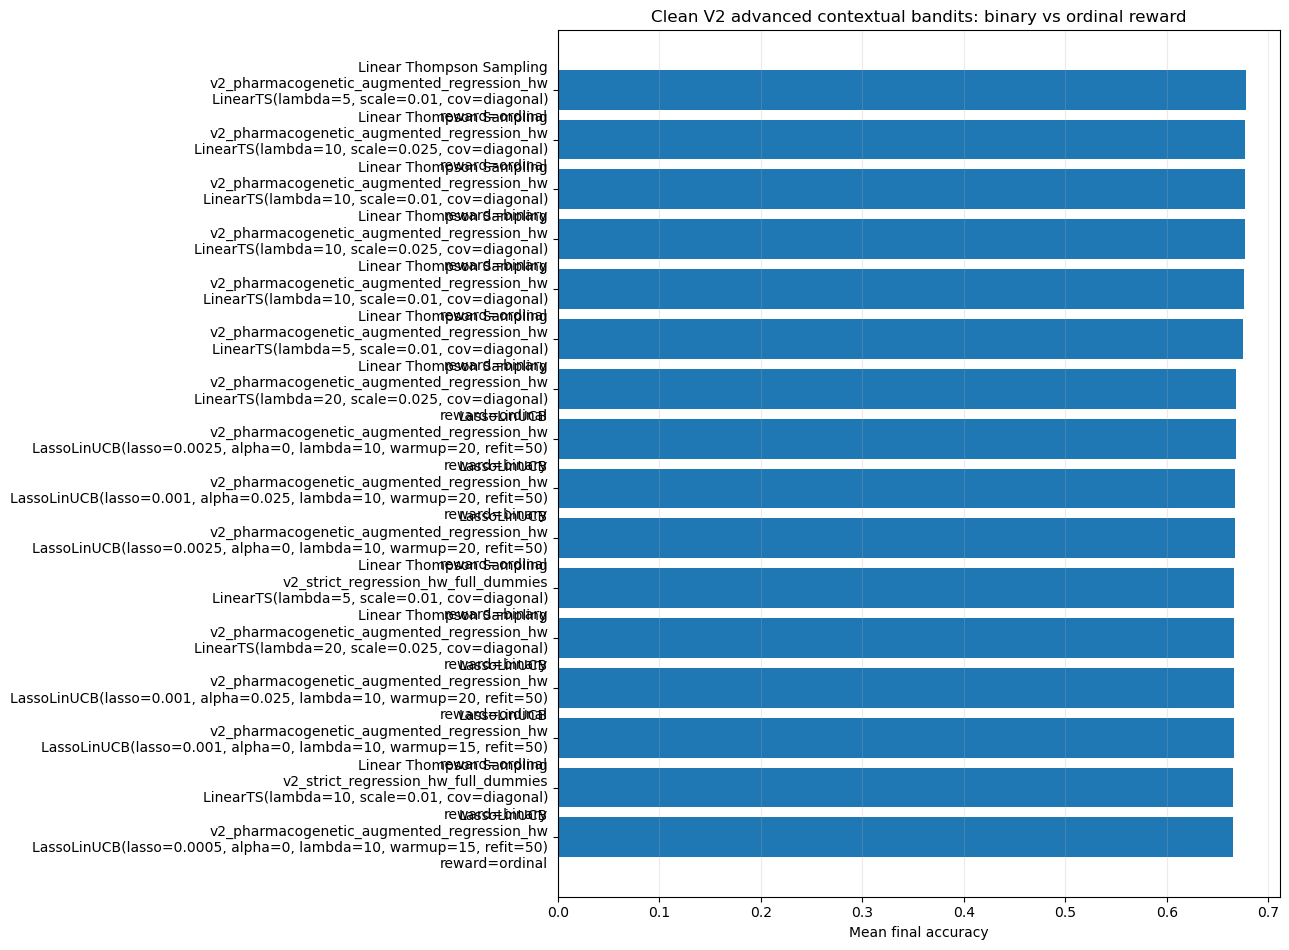

In [11]:
fig, ax = plot_advanced_leaderboard(
    advanced_summary,
    top_n=16,
    title='Clean V2 advanced contextual bandits: binary vs ordinal reward',
)
fig.savefig(RESULTS_DIR / 'advanced_bandit_reward_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Reward comparison checkpoint

The ordinal reward changes what the online model learns from mistakes, but the leaderboard still uses exact bucket accuracy. Check class-wise recall and severe-error rates before deciding whether ordinal reward is genuinely better.

In [12]:
comparison_cols = [
    'algorithm_family', 'reward_scheme', 'feature_set', 'config_name',
    'final_accuracy_mean', 'final_accuracy_ci95', 'final_reward_mean',
    'late_accuracy_mean', 'final_regret_mean',
]
advanced_summary[comparison_cols].sort_values('final_accuracy_mean', ascending=False).head(30)

,algorithm_family,reward_scheme,feature_set,config_name,final_accuracy_mean,final_accuracy_ci95,final_reward_mean,late_accuracy_mean,final_regret_mean
0,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",0.677460,0.000542,0.675651,0.695333,1793.000000
1,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.677038,0.002020,0.675410,0.694000,1794.333333
2,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.676978,0.001563,0.676978,0.693333,1785.666667
3,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.676556,0.004140,0.676556,0.695333,1788.000000
4,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.675772,0.003842,0.674385,0.688667,1800.000000
5,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",0.674747,0.003996,0.674747,0.694000,1798.000000
6,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",0.668234,0.007978,0.667149,0.689333,1840.000000
16,LassoLinUCB,binary,v2_pharmacogenetic_augmented_regression_hw,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",0.668174,0.005328,0.668174,0.684000,1834.333333
17,LassoLinUCB,binary,v2_pharmacogenetic_augmented_regression_hw,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",0.667451,0.004802,0.667451,0.690667,1838.333333
18,LassoLinUCB,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",0.667390,0.002726,0.663350,0.686667,1861.000000
